In [1]:
# environment_version = "6"
# MAGIC %md
# MAGIC # 13 - Final Model | Shared handover from Member 4
# MAGIC ## 1. What I am doing
# MAGIC Evaluate the validation-selected model on the final test split and verify raw-input prediction.
# MAGIC ## 2. Why I am doing it
# MAGIC An untouched temporal holdout estimates performance on later incidents. The same saved
# MAGIC preprocessing must be used by the backend; the model predicts crime type, not future crime occurrence.

## 3. Install notebook libraries
Run on Databricks serverless notebook compute using Python 3.11 or newer.
Dependencies are installed directly in this cell; no separate setup file is needed.
Use the same pinned versions in every Member 4 notebook.
Run the restart cell immediately after installation, then continue with Imports.

%pip install numpy==2.4.6 scipy==1.17.1 scikit-learn==1.9.0 joblib==1.5.3 matplotlib==3.11.0 xgboost==3.4.1
%pip install "pandas<3.0"

In [2]:
if 'dbutils' in globals() and hasattr(dbutils, 'library'):
    dbutils.library.restartPython()


## 4. Imports

In [3]:
from pathlib import Path
import importlib.metadata
import json
import time
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

## 5. Databricks table, artifact location and split configuration
Keep these settings identical in all Member 4 notebooks.
Train: before July 2025; validation: July-December 2025; test: from January 2026.
The first baseline run freezes the clean-table snapshot in a shared volume.
Later notebooks reuse the same data and fitted preprocessing.
Change EXPERIMENT everywhere to intentionally start a new experiment.

In [4]:
CATALOG_SCHEMA = 'workspace.default'
SOURCE_TABLE = f'{CATALOG_SCHEMA}.chicago_crime_clean'
VOLUME_NAME = 'chicago_crime_member4'
ARTIFACT_ROOT = Path(f'/Volumes/workspace/default/{VOLUME_NAME}')
EXPERIMENT = 'member4_v1'
SEED = 42
MAX_LOCAL_ROWS = 750000
TRAIN_END = '2025-07-01'
VALIDATION_END = '2026-01-01'
MODEL_NAMES = ['Logistic_Regression', 'Decision_Tree', 'Random_Forest', 'XGBoost']
RAW_FEATURES = ['date', 'location_description', 'beat', 'district', 'ward', 'community_area', 'latitude', 'longitude', 'domestic']
CATEGORICAL = ['location_description', 'beat', 'district', 'ward', 'community_area', 'area_group']
NUMERIC = ['latitude', 'longitude', 'year', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'is_weekend', 'domestic_int', 'coordinates_missing']
LEAKAGE_EXCLUSIONS = ['iucr', 'description', 'fbi_code', 'arrest', 'updated_on', 'case_number']

## 6. Local data and evaluation functions
These cells define the functions used by this notebook. Execute them from top to bottom.
All required code is included here; there are no imports from another project notebook.

In [5]:
def experiment_dir():
    try:
        if ARTIFACT_ROOT.exists() or str(ARTIFACT_ROOT).startswith('/Volumes'):
            exp = ARTIFACT_ROOT / EXPERIMENT
            exp.mkdir(parents=True, exist_ok=True)
            return exp
    except Exception:
        pass
    # Local fallback path
    curr = Path.cwd().resolve()
    for p in [curr] + list(curr.parents):
        if (p / 'databricks').exists():
            exp = p / 'databricks' / 'artifacts' / VOLUME_NAME / EXPERIMENT
            exp.mkdir(parents=True, exist_ok=True)
            return exp
    exp = curr / 'artifacts' / VOLUME_NAME / EXPERIMENT
    exp.mkdir(parents=True, exist_ok=True)
    return exp


In [6]:
def save_json(path, value):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    Path(path).write_text(json.dumps(value, indent=2, allow_nan=False), encoding="utf-8")

In [7]:
def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))

In [8]:
def versions():
    return {p: importlib.metadata.version(p) for p in
            ["numpy", "pandas", "scipy", "scikit-learn", "joblib", "matplotlib"]}

In [9]:
def configuration():
    return dict(source_table=SOURCE_TABLE, train_end=TRAIN_END, validation_end=VALIDATION_END,
                seed=SEED, raw_features=RAW_FEATURES, categorical=CATEGORICAL, numeric=NUMERIC,
                preprocessing_version=1)

In [10]:
def load_manifest():
    path = experiment_dir() / "manifest.json"
    if not path.exists():
        raise RuntimeError("Run a baseline notebook (07-10) to prepare the shared data first.")
    manifest = read_json(path)
    if manifest["configuration"] != configuration():
        raise ValueError("Configuration changed. Use a new EXPERIMENT and prepare data again.")
    if manifest["versions"] != versions():
        raise ValueError("Package versions differ from preparation. Use the saved environment versions.")
    return manifest

In [11]:
def engineer_features(raw, coordinate_medians):
    """Identical deterministic transformation for training and backend prediction."""
    missing = set(RAW_FEATURES) - set(raw.columns)
    if missing:
        raise ValueError(f"Missing input columns: {sorted(missing)}")
    x = raw[RAW_FEATURES].copy()
    dates = pd.to_datetime(x["date"], errors="coerce")
    if dates.isna().any() or dates.dt.tz is not None:
        raise ValueError("date must contain valid timezone-naive Chicago incident timestamps.")
    x["year"] = dates.dt.year
    hour, weekday, month = dates.dt.hour, dates.dt.dayofweek, dates.dt.month
    for name, values, period in [("hour", hour, 24), ("day_of_week", weekday, 7), ("month", month - 1, 12)]:
        x[f"{name}_sin"] = np.sin(2 * np.pi * values / period)
        x[f"{name}_cos"] = np.cos(2 * np.pi * values / period)
    x["is_weekend"] = (weekday >= 5).astype(int)
    domestic = x["domestic"].astype("string").str.lower().str.strip()
    if not domestic.dropna().isin(["true", "false", "1", "0", "1.0", "0.0"]).all():
        raise ValueError("domestic must be a Boolean, 0/1, or missing.")
    # Matches Member 3: missing domestic is mapped to 0.
    x["domestic_int"] = domestic.isin(["true", "1", "1.0"]).astype(int)
    for col in ["latitude", "longitude"]:
        x[col] = pd.to_numeric(x[col], errors="raise").astype(float)
        if np.isinf(x[col]).any():
            raise ValueError(f"Infinite {col} values are invalid.")
    absent = x[["latitude", "longitude"]].isna().any(axis=1)
    x["coordinates_missing"] = absent.astype(int)
    north = x["latitude"] >= coordinate_medians["latitude"]
    west = x["longitude"] < coordinate_medians["longitude"]
    x["area_group"] = np.select(
        [absent, north & west, north & ~west, ~north & west],
        ["Unknown", "North-West", "North-East", "South-West"], default="South-East",
    )
    for col in CATEGORICAL:
        if col in ["beat", "district", "ward", "community_area"]:
            codes = pd.to_numeric(x[col], errors="raise")
            if (codes.dropna() % 1 != 0).any():
                raise ValueError(f"{col} must contain whole-number geographic codes.")
            x[col] = codes.astype("Int64").astype("string")
        x[col] = x[col].astype("string").fillna("Unknown").astype(str)
    return x[CATEGORICAL + NUMERIC]

In [12]:
def load_split(split):
    load_manifest()
    return (sparse.load_npz(experiment_dir() / f"{split}_features.npz"),
            np.load(experiment_dir() / f"{split}_labels.npy"))

In [13]:
def metric_details(y_true, y_pred, classes):
    labels = list(range(len(classes)))
    names = list(classes)
    if np.any(y_true == -1):
        labels.append(-1)
        names.append("UNSEEN_IN_TRAINING")
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0,
    )
    metrics = dict(accuracy=float(accuracy_score(y_true, y_pred)),
                   macro_precision=float(precision.mean()), macro_recall=float(recall.mean()),
                   macro_f1=float(f1.mean()), weighted_f1=float(np.average(f1, weights=support)))
    per_class = pd.DataFrame(dict(primary_type=names, precision=precision, recall=recall, f1=f1, support=support))
    cm = pd.DataFrame(confusion_matrix(y_true, y_pred, labels=labels), index=names, columns=names)
    return metrics, per_class, cm

In [14]:
def evaluate(model, x, y, classes):
    start = time.perf_counter()
    prediction = model.predict(x)
    metrics, per_class, cm = metric_details(y, prediction, classes)
    metrics["evaluation_seconds"] = time.perf_counter() - start
    return metrics, per_class, cm

In [15]:
def save_evaluation(directory, split, metrics, per_class, cm):
    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    save_json(directory / f"{split}_metrics.json", metrics)
    per_class.to_csv(directory / f"{split}_per_class.csv", index=False)
    cm.to_csv(directory / f"{split}_confusion_matrix.csv", index_label="actual / predicted")
    fig, ax = plt.subplots(figsize=(13, 11))
    normalized = cm.to_numpy() / np.maximum(cm.sum(axis=1).to_numpy()[:, None], 1)
    plot = ax.imshow(normalized, cmap="Blues", vmin=0, vmax=1)
    ax.set(xticks=range(len(cm)), yticks=range(len(cm)), xticklabels=cm.columns,
           yticklabels=cm.index, xlabel="Predicted crime type", ylabel="Actual crime type",
           title=f"{split.title()} confusion matrix (row-normalized)")
    plt.setp(ax.get_xticklabels(), rotation=90, fontsize=7)
    plt.setp(ax.get_yticklabels(), fontsize=7)
    fig.colorbar(plot, ax=ax)
    fig.tight_layout()
    fig.savefig(directory / f"{split}_confusion_matrix.png", dpi=150)
    plt.close(fig)

In [16]:
def show_confusion(path):
    fig, ax = plt.subplots(figsize=(13, 11))
    ax.imshow(plt.imread(path))
    ax.axis("off")
    fig.tight_layout()
    plt.show()
    plt.close(fig)

In [17]:
def interpretation(per_class, cm):
    supported = per_class.loc[per_class.support > 0].sort_values("f1")
    errors = cm.to_numpy().copy()
    np.fill_diagonal(errors, 0)
    lines = []
    if not supported.empty:
        best, worst = supported.iloc[-1], supported.iloc[0]
        lines += [f"Strongest supported class: {best.primary_type} (F1={best.f1:.3f}).",
                  f"Weakest supported class: {worst.primary_type} (F1={worst.f1:.3f}, support={int(worst.support)})."]
    if errors.max() > 0:
        i, j = np.unravel_index(errors.argmax(), errors.shape)
        lines.append(f"Largest error pair: {cm.index[i]} predicted as {cm.columns[j]} ({errors[i, j]} rows).")
    lines.append("Compare macro and weighted F1: common classes can conceal weak rare-class performance.")
    return "\n".join(lines)

In [18]:
def predict_raw(bundle, raw_rows):
    """Backend entry point: supply a pandas DataFrame with RAW_FEATURES only."""
    frame = engineer_features(raw_rows, bundle["coordinate_medians"])
    features = sparse.csr_matrix(bundle["preprocessor"].transform(frame), dtype=np.float32)
    codes = bundle["model"].predict(features).astype(int)
    return np.asarray(bundle["classes"])[codes]

In [19]:
def final_evaluation():
    final = experiment_dir() / "final"
    if not (final / "selection.json").exists():
        raise RuntimeError("Run notebook 12 to freeze the selected model first.")
    selection = read_json(final / "selection.json")
    manifest = load_manifest()
    if selection["experiment_id"] != manifest["experiment_id"]:
        raise ValueError("Selected model belongs to a different data snapshot.")
    if (final / "test_complete.json").exists():
        print("Returning the recorded test evaluation. Do not use it to retune.")
        return read_json(final / "test_complete.json")
    bundle = joblib.load(final / "final_model_bundle.joblib")
    x_test, y_test = load_split("test")
    metrics, per_class, cm = evaluate(bundle["model"], x_test, y_test, bundle["classes"])
    save_evaluation(final, "test", metrics, per_class, cm)
    (final / "test_findings.txt").write_text(interpretation(per_class, cm), encoding="utf-8")
    save_json(final / "test_complete.json", metrics)
    return metrics

In [20]:
# MEMBER4 EXECUTION CELLS

## 7. Code / analysis
Selection must already be frozen by notebook 12. Reruns return the recorded test metrics.

,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,evaluation_seconds
0,0.363495,0.232919,0.119115,0.120228,0.295238,13.995667


,primary_type,precision,recall,f1,support
0,ARSON,0.000000,0.000000,0.000000,273
1,ASSAULT,0.212828,0.014653,0.027418,14946
2,BATTERY,0.479346,0.650630,0.552006,30409
3,BURGLARY,0.428793,0.084460,0.141123,9839
4,CONCEALED CARRY LICENSE VIOLATION,0.283019,0.082873,0.128205,181
5,CRIMINAL DAMAGE,0.249833,0.103183,0.146048,18094
6,CRIMINAL SEXUAL ASSAULT,0.474006,0.121569,0.193508,1275
7,CRIMINAL TRESPASS,0.342697,0.015510,0.029676,3933
8,DECEPTIVE PRACTICE,0.392205,0.325887,0.355984,9356
9,GAMBLING,0.000000,0.000000,0.000000,12


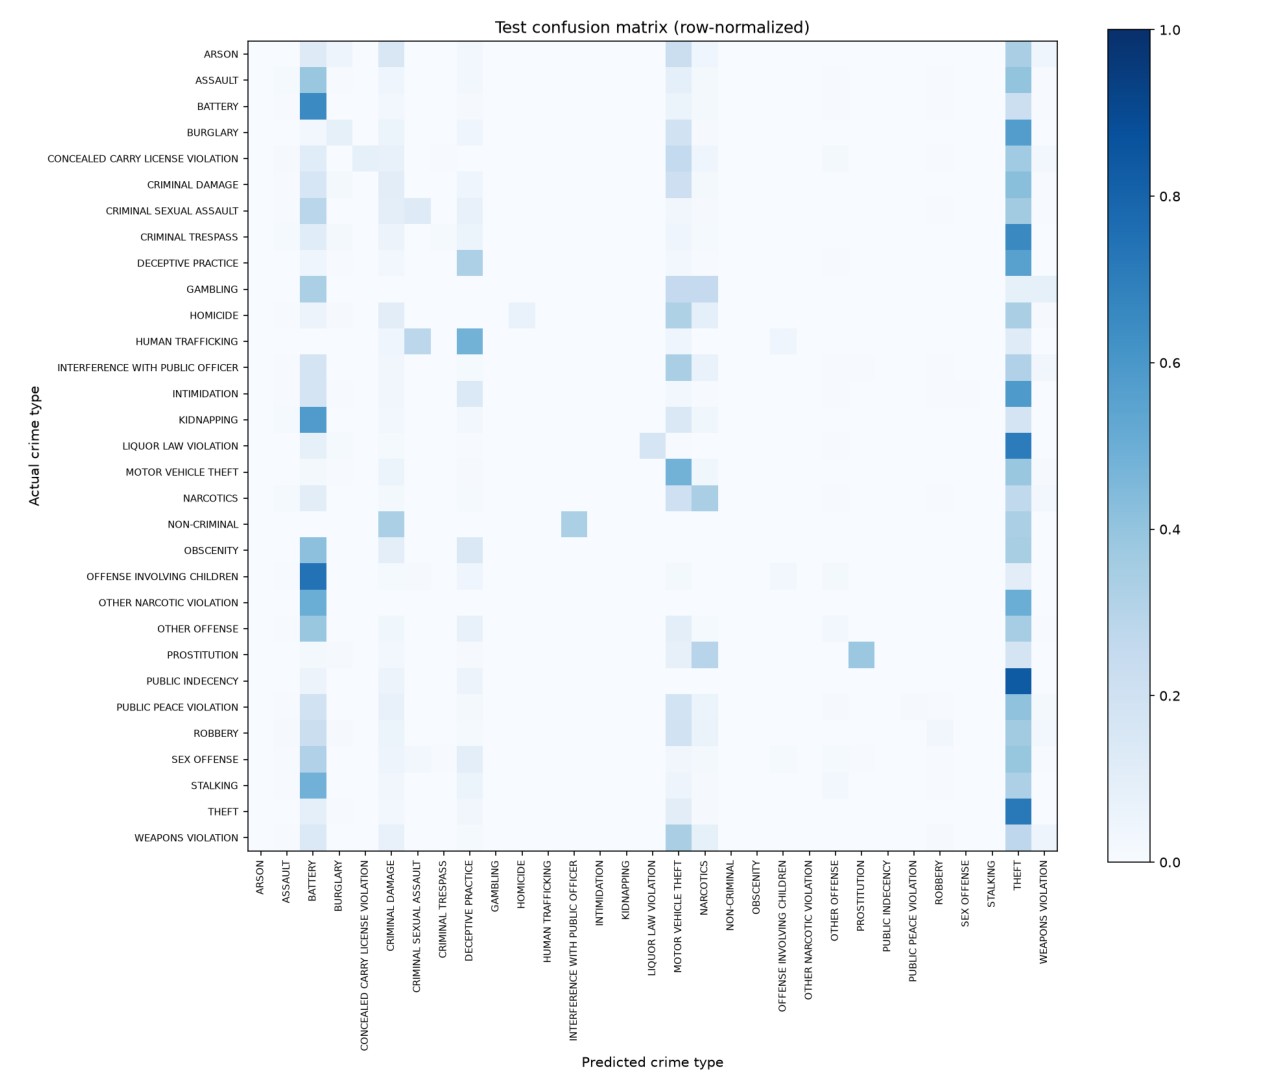

Strongest supported class: BATTERY (F1=0.552).
Weakest supported class: ARSON (F1=0.000, support=273).
Largest error pair: CRIMINAL DAMAGE predicted as THEFT (7683 rows).
Compare macro and weighted F1: common classes can conceal weak rare-class performance.


In [21]:
test_metrics = final_evaluation()
display(pd.DataFrame([test_metrics]))
final_directory = experiment_dir() / "final"
display(pd.read_csv(final_directory / "test_per_class.csv"))
show_confusion(final_directory / "test_confusion_matrix.png")
print((final_directory / "test_findings.txt").read_text(encoding="utf-8"))

In [22]:
bundle = joblib.load(final_directory / "final_model_bundle.joblib")
example_inputs = joblib.load(experiment_dir() / "train_rows.joblib")[RAW_FEATURES].head(5)
display(example_inputs)
print("Predicted primary_type:", predict_raw(bundle, example_inputs).tolist())
print("Required backend fields:", RAW_FEATURES)
print("Feature names:", bundle["feature_names"])

,date,location_description,beat,district,ward,community_area,latitude,longitude,domestic
0,2024-01-01 05:30:00,ALLEY,1533,15,29.0,25.0,41.874896,-87.751134,False
1,2024-01-01 05:30:00,APARTMENT,1412,14,35.0,22.0,41.929276,-87.713263,True
2,2024-01-01 05:30:00,STREET,1414,14,1.0,22.0,41.925073,-87.700887,True
3,2024-01-01 05:30:00,RESIDENCE,524,5,21.0,53.0,41.671722,-87.645362,True
4,2024-01-01 05:30:00,STREET,414,4,7.0,43.0,41.754517,-87.569945,False


Predicted primary_type: ['WEAPONS VIOLATION', 'BATTERY', 'BATTERY', 'BATTERY', 'MOTOR VEHICLE THEFT']
Required backend fields: ['date', 'location_description', 'beat', 'district', 'ward', 'community_area', 'latitude', 'longitude', 'domestic']
Feature names: ['categories__location_description_ABANDONED BUILDING', 'categories__location_description_AIRCRAFT', 'categories__location_description_AIRPORT BUILDING NON-TERMINAL - NON-SECURE AREA', 'categories__location_description_AIRPORT BUILDING NON-TERMINAL - SECURE AREA', 'categories__location_description_AIRPORT EXTERIOR - NON-SECURE AREA', 'categories__location_description_AIRPORT EXTERIOR - SECURE AREA', 'categories__location_description_AIRPORT PARKING LOT', 'categories__location_description_AIRPORT TERMINAL LOWER LEVEL - NON-SECURE AREA', 'categories__location_description_AIRPORT TERMINAL LOWER LEVEL - SECURE AREA', 'categories__location_description_AIRPORT TERMINAL MEZZANINE - NON-SECURE AREA', 'categories__location_description_AIRPOR

## 8. Findings / conclusion
Hand over final_model_bundle.joblib, environment_versions.json and manifest.json.
The engineer_features and predict_raw functions are included in this notebook.
Backend developers can copy these functions and the feature constants into their application,
load the trusted bundle with joblib.load, and call predict_raw(bundle, pandas_dataframe).
Predictions are incident crime types, not forecasts of future crime occurrence.
Run 17_Report_Evidence/Member_4/Member_4_Results to export the completed results PDF.